In [22]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Y')

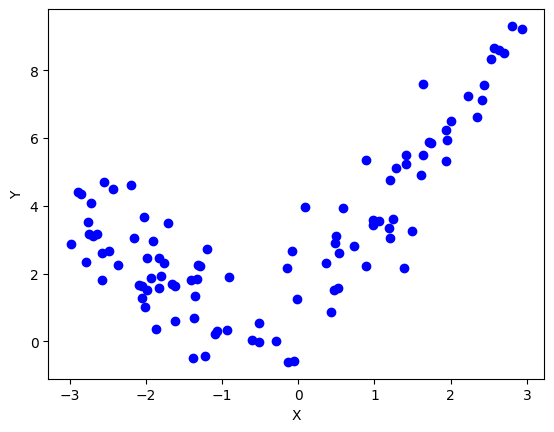

In [23]:
x= 6 * np.random.rand(100,1) - 3
y= 0.5 * x**2 + x + 2 + np.random.randn(100,1)
plt.scatter(x,y, color='blue')
plt.xlabel('X')
plt.ylabel('Y')



In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [25]:
from sklearn.linear_model import LinearRegression
lin_reg= LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
from sklearn.metrics import r2_score
score = r2_score(y_test, lin_reg.predict(x_test))
print(score)

0.5638343989631971


Text(0, 0.5, 'Y')

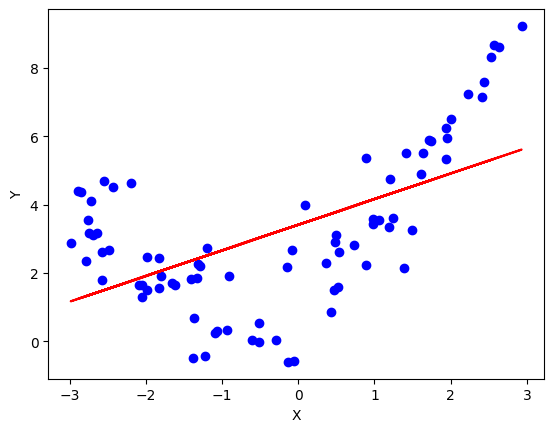

In [27]:
plt.plot(x_train, lin_reg.predict(x_train), color='red')
plt.scatter(x_train, y_train, color='blue')
plt.xlabel('X')
plt.ylabel('Y')

In [28]:
from sklearn.preprocessing import PolynomialFeatures
poly= PolynomialFeatures(degree=2, include_bias=True)
x_poly= poly.fit_transform(x_train)
x_test_poly= poly.transform(x_test)


In [29]:
from sklearn.metrics import r2_score
lin_reg= LinearRegression()
lin_reg.fit(x_poly, y_train)
y_pred= lin_reg.predict(x_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8007740929748904


In [30]:
print(lin_reg.coef_)
print(lin_reg.intercept_)

[[0.         1.04025017 0.64054958]]
[1.49736098]


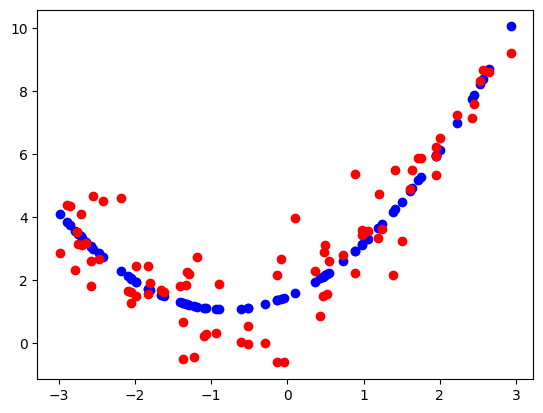

In [31]:
plt.scatter(x_train,lin_reg.predict(x_poly), color='blue')
plt.scatter(x_train, y_train, color='red')

In [32]:
from sklearn.preprocessing import PolynomialFeatures
poly= PolynomialFeatures(degree=3, include_bias=True)
x_poly= poly.fit_transform(x_train)
x_test_poly= poly.transform(x_test)

In [33]:
x_poly


array([[ 1.00000000e+00,  2.63903698e+00,  6.96451620e+00,
         1.83796158e+01],
       [ 1.00000000e+00, -1.40331723e+00,  1.96929924e+00,
        -2.76355154e+00],
       [ 1.00000000e+00, -2.98557792e+00,  8.91367554e+00,
        -2.66124729e+01],
       [ 1.00000000e+00, -1.31350082e+00,  1.72528439e+00,
        -2.26616246e+00],
       [ 1.00000000e+00, -1.06229403e+00,  1.12846860e+00,
        -1.19876545e+00],
       [ 1.00000000e+00, -1.82326077e+00,  3.32427983e+00,
        -6.06102899e+00],
       [ 1.00000000e+00, -2.64257616e+00,  6.98320878e+00,
        -1.84536611e+01],
       [ 1.00000000e+00, -1.38278295e-01,  1.91208868e-02,
        -2.64400362e-03],
       [ 1.00000000e+00, -1.32692114e+00,  1.76071971e+00,
        -2.33633621e+00],
       [ 1.00000000e+00, -2.85424972e+00,  8.14674148e+00,
        -2.32528346e+01],
       [ 1.00000000e+00,  2.44289988e+00,  5.96775983e+00,
         1.45786398e+01],
       [ 1.00000000e+00,  2.56756674e+00,  6.59239899e+00,
      

In [34]:
from sklearn.metrics import r2_score
lin_reg= LinearRegression()
lin_reg.fit(x_poly, y_train)
y_pred= lin_reg.predict(x_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8052288214400019


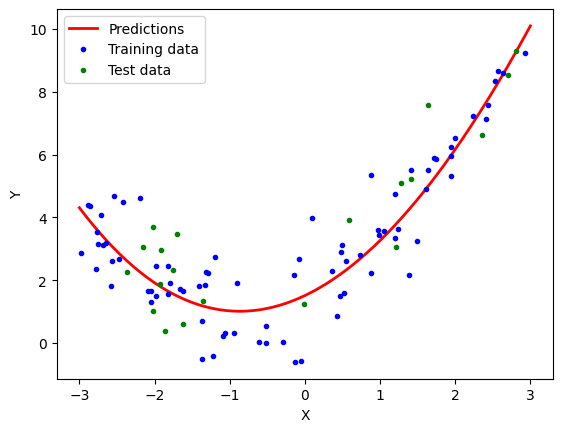

In [35]:
x_new= np.linspace(-3,3,200).reshape(200,1)
x_new_poly= poly.transform(x_new)
y_new= lin_reg.predict(x_new_poly)
plt.plot(x_new, y_new, 'r-', label='Predictions', linewidth=2)
plt.plot(x_train, y_train, 'b.', label='Training data')
plt.plot(x_test, y_test, 'g.', label='Test data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()    
plt.show()

In [36]:
from sklearn.pipeline import Pipeline

In [37]:
def polynomial_regression(degree):
    x_new = np.linspace(-3,3,200).reshape(200,1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_reg_pipeline = Pipeline([('poly_features', poly_features), ('lin_reg', lin_reg)])
    poly_reg_pipeline.fit(x_train, y_train)
    y_new = poly_reg_pipeline.predict(x_new)

    plt.plot(x_new, y_new, 'r-', label='Predictions', linewidth=2)
    plt.plot(x_train, y_train, 'b.', label='Training data', linewidth=3)
    plt.plot(x_test, y_test, 'g.', label='Test data', linewidth=3)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis([-4, 4, 0, 10])
    plt.legend()
    plt.title(f'Polynomial Regression (degree={degree})')
    plt.show()


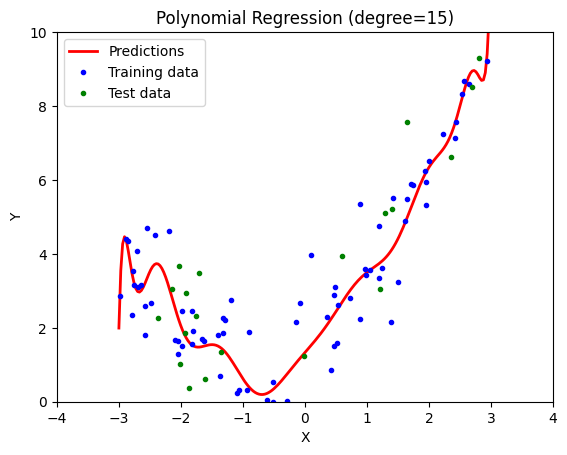

In [43]:
polynomial_regression(degree=15)